<a href="https://colab.research.google.com/github/RM-28/multimodal-pain-assesment/blob/fusion/fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project setup

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
!ls "/content/gdrive/MyDrive/Colab Notebooks/AI570_Deep_Learning/TeamProject"

fusion.ipynb  multimodal-pain-assesment-main.zip


In [7]:
zip_path = "/content/gdrive/MyDrive/Colab Notebooks/AI570_Deep_Learning/TeamProject/multimodal-pain-assesment-main.zip"
extract_path = "/content/team_project"

!unzip -q -o "$zip_path" -d "$extract_path"
!ls "$extract_path"

multimodal-pain-assesment-main


In [8]:
%cd /content/team_project/multimodal-pain-assesment-main
!ls

/content/team_project/multimodal-pain-assesment-main
CONTRIBUTING.md  notebooks	 requirements.txt  src
data		 pyproject.toml  results	   templates
docs		 README.md	 scripts	   tests


In [10]:
# install the project
!pip install -e .

Obtaining file:///content/team_project/multimodal-pain-assesment-main
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for painnet (pyproject.toml) ... done
  Created wheel for painnet: filename=painnet-0.1.0-0.editable-py3-none-any.whl size=3790 sha256=30fc5e8d19870b98f594c3833bbdad4b279e47b9a6e1d5c6e341fb798826a114
  Stored in directory: /tmp/pip-ephem-wheel-cache-dfq7hmyr/wheels/98/39/dc/1c3978ce024a1fa86ba77549cb405752b4dbf58b7362695941
Successfully built painnet


In [12]:
%cd /content/team_project/multimodal-pain-assesment-main
!ls
!find . -maxdepth 3 -type d -name "painnet"

/content/team_project/multimodal-pain-assesment-main
CONTRIBUTING.md  notebooks	 requirements.txt  src
data		 pyproject.toml  results	   templates
docs		 README.md	 scripts	   tests
./src/painnet


In [13]:
!pip install -e .

Obtaining file:///content/team_project/multimodal-pain-assesment-main
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for painnet (pyproject.toml) ... done
  Created wheel for painnet: filename=painnet-0.1.0-0.editable-py3-none-any.whl size=3790 sha256=37d9d9e9d33d3c41fe840009e575ec07fe5e31143048137c80870829265e75ba
  Stored in directory: /tmp/pip-ephem-wheel-cache-z281a2mj/wheels/98/39/dc/1c3978ce024a1fa86ba77549cb405752b4dbf58b7362695941
Successfully built painnet
  Attempting uninstall: painnet
    Found existing installation: painnet 0.1.0
    Uninstalling painnet-0.1.0:
      Successfully uninstalled painnet-0.1.0


In [14]:
import sys

project_path = "/content/team_project/multimodal-pain-assesment-main"
src_path = project_path + "/src"

if src_path not in sys.path:
    sys.path.insert(0, src_path)

import painnet
print("painnet imported from:", painnet.__file__)

painnet imported from: /content/team_project/multimodal-pain-assesment-main/src/painnet/__init__.py


In [15]:
from painnet import watch, windows, splits, models, evaluate

print("painnet imported successfully")

painnet imported successfully


# Build the paired dataset

In [18]:
# Now build the paired dataset
# Use the existing watch.build_fusion_dataset()

# Before building the dataset, we need to ensure the raw data is available.
# The error indicates that EEG data is missing, and the watch data processing was skipped.
# We need to run the data acquisition script provided by the project with the --watch flag.

# Run the data acquisition script to process both EEG and watch data
!python scripts/get_data.py --watch

X_eeg, X_watch, y, groups = watch.build_fusion_dataset()
y_int = windows.encode_labels(y)

print("EEG shape:", X_eeg.shape)
print("Wristband shape:", X_watch.shape)
print("Labels shape:", y_int.shape)
print("Groups shape:", groups.shape)
print("Number of subjects:", len(set(groups)))

PhysioPain dataset fetch
  zip already present (1.26 GB), skipping download
  extracting 640 files (4884.8 MB) ...
  done
  removed zip

  EEG subject files found: 83 (expected 83)
Loaded watch data with shape: (440428, 9)
Participants: 86
EEG subjects: 83 Watch subjects: 86 Common subjects: 77
Pain windows:  5936
X_eeg shape: (5936, 60, 10)
X_watch shape: (5936, 240, 6)
Class Participants Windows
no_pain                    15     1143
headache                   27     2103
back_pain                  25     1882
menstrual_pain             10      808
EEG shape: (5936, 60, 10)
Wristband shape: (5936, 240, 6)
Labels shape: (5936,)
Groups shape: (5936,)
Number of subjects: 77


# Split subjects and do a smoke test

In [19]:
import gc
import time
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from painnet import config, evaluate, models, splits, watch, windows

In [20]:
# Create shared train, validation, and test folds
outer_folds = list(
    splits.subject_folds(
        groups,
        y_int,
        n_splits=5
    )
)

cv_folds = []

for fold_number, (outer_train_idx, test_idx) in enumerate(outer_folds, start=1):

    # Make a subject-separated validation set from the outer training data
    inner_splitter = splits.subject_folds(
        groups[outer_train_idx],
        y_int[outer_train_idx],
        n_splits=4
    )

    inner_train_rel, val_rel = next(inner_splitter)

    train_idx = outer_train_idx[inner_train_rel]
    val_idx = outer_train_idx[val_rel]

    train_subjects = set(groups[train_idx])
    val_subjects = set(groups[val_idx])
    test_subjects = set(groups[test_idx])

    # Confirm complete subject separation
    assert train_subjects.isdisjoint(val_subjects)
    assert train_subjects.isdisjoint(test_subjects)
    assert val_subjects.isdisjoint(test_subjects)

    cv_folds.append((train_idx, val_idx, test_idx))

    print(
        f"Fold {fold_number}: "
        f"train={len(train_subjects)} subjects, "
        f"validation={len(val_subjects)} subjects, "
        f"test={len(test_subjects)} subjects"
    )

Fold 1: train=47 subjects, validation=15 subjects, test=15 subjects
Fold 2: train=46 subjects, validation=16 subjects, test=15 subjects
Fold 3: train=45 subjects, validation=16 subjects, test=16 subjects
Fold 4: train=47 subjects, validation=14 subjects, test=16 subjects
Fold 5: train=46 subjects, validation=16 subjects, test=15 subjects


# Test 1: matched CNN ablation
## EEG CNN vs wristband CNN vs dual-branch CNN
### This answers the question: Does adding the second modality help within the same architecture family?
### This step test three models:

  * EEG-only 1D CNN
  * Wristband-only 1D CNN
  * EEG + wristband fusion dual branch 1D CNN




In [22]:
def select_input(model_name, indices):
    """Return the correct inputs for one model."""

    if model_name == "eeg_only":
        return X_eeg[indices]

    if model_name == "watch_only":
        return X_watch[indices]

    if model_name == "fusion":
        return [
            X_eeg[indices],
            X_watch[indices]
        ]

    raise ValueError(f"Unknown model: {model_name}")


def build_model(model_name):
    """Build and compile a fresh model."""

    keras.backend.clear_session()

    if model_name == "eeg_only":
        model = models.build_cnn1d(X_eeg.shape[1:])

    elif model_name == "watch_only":
        model = models.build_cnn1d(X_watch.shape[1:])

    elif model_name == "fusion":
        model = models.build_fusion(
            X_eeg.shape[1:],
            X_watch.shape[1:]
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return models.compile_model(model)

In [23]:
# Now define the cross-validation experiment:
def run_experiment(
    model_name,
    folds,
    epochs=60,
    batch_size=64,
    verbose=2
):
    fold_rows = []

    # Out-of-fold predictions
    oof_predictions = np.full(len(y_int), -1, dtype=int)
    oof_probabilities = np.full(
        (len(y_int), len(config.PAIN_CLASSES)),
        np.nan,
        dtype=np.float32
    )

    histories = []

    for fold_number, (train_idx, val_idx, test_idx) in enumerate(
        folds,
        start=1
    ):
        print(f"\n{'=' * 60}")
        print(f"{model_name}: fold {fold_number}/{len(folds)}")
        print(f"{'=' * 60}")

        start_time = time.time()

        model = build_model(model_name)

        history = model.fit(
            select_input(model_name, train_idx),
            y_int[train_idx],

            validation_data=(
                select_input(model_name, val_idx),
                y_int[val_idx]
            ),

            epochs=epochs,
            batch_size=batch_size,
            class_weight=windows.class_weights(y_int[train_idx]),
            callbacks=models.default_callbacks(patience=8),
            verbose=verbose
        )

        probabilities = model.predict(
            select_input(model_name, test_idx),
            batch_size=batch_size,
            verbose=0
        )

        predictions = probabilities.argmax(axis=1)

        oof_predictions[test_idx] = predictions
        oof_probabilities[test_idx] = probabilities

        row = {
            "model": model_name,
            "fold": fold_number,
            **evaluate.fold_metrics(
                y_int[test_idx],
                predictions
            ),
            **evaluate.per_class_f1(
                y_int[test_idx],
                predictions
            ),
            "epochs_ran": len(history.history["loss"]),
            "train_subjects": len(set(groups[train_idx])),
            "validation_subjects": len(set(groups[val_idx])),
            "test_subjects": len(set(groups[test_idx])),
            "seconds": time.time() - start_time
        }

        fold_rows.append(row)
        histories.append(history.history)

        print(
            f"Macro-F1: {row['macro_f1']:.3f} | "
            f"Accuracy: {row['accuracy']:.3f} | "
            f"Balanced accuracy: {row['balanced_acc']:.3f}"
        )

        del model
        keras.backend.clear_session()
        gc.collect()

    return (
        pd.DataFrame(fold_rows),
        oof_predictions,
        oof_probabilities,
        histories
    )

In [24]:
# smoke test
smoke_results, smoke_predictions, smoke_probabilities, smoke_histories = (
    run_experiment(
        model_name="fusion",
        folds=cv_folds[:1],
        epochs=2,
        batch_size=64,
        verbose=1
    )
)

display(smoke_results)


fusion: fold 1/1
Epoch 1/2
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - accuracy: 0.3255 - loss: 1.2261 - val_accuracy: 0.3813 - val_loss: 1.3727 - learning_rate: 0.0010
Epoch 2/2
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4233 - loss: 1.1148 - val_accuracy: 0.2489 - val_loss: 1.3926 - learning_rate: 0.0010


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Macro-F1: 0.146 | Accuracy: 0.237 | Balanced accuracy: 0.208


,model,fold,macro_f1,weighted_f1,balanced_acc,accuracy,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain,epochs_ran,train_subjects,validation_subjects,test_subjects,seconds
0,fusion,1,0.145986,0.261999,0.20803,0.237201,0.0,0.319645,0.2643,0.0,2,47,15,15,19.414178


In [25]:
# The smoke test passed, now run the complete model
all_fold_results = []
all_predictions = {}
all_probabilities = {}
all_histories = {}

for model_name in ["eeg_only", "watch_only", "fusion"]:

    fold_results, predictions, probabilities, histories = run_experiment(
        model_name=model_name,
        folds=cv_folds,
        epochs=60,
        batch_size=64,
        verbose=2
    )

    all_fold_results.append(fold_results)
    all_predictions[model_name] = predictions
    all_probabilities[model_name] = probabilities
    all_histories[model_name] = histories

results_df = pd.concat(all_fold_results, ignore_index=True)

display(results_df)


eeg_only: fold 1/5
Epoch 1/60
57/57 - 7s - 121ms/step - accuracy: 0.3280 - loss: 1.2422 - val_accuracy: 0.0450 - val_loss: 1.4670 - learning_rate: 0.0010
Epoch 2/60
57/57 - 0s - 9ms/step - accuracy: 0.4167 - loss: 1.1584 - val_accuracy: 0.0688 - val_loss: 1.5354 - learning_rate: 0.0010
Epoch 3/60
57/57 - 1s - 10ms/step - accuracy: 0.4682 - loss: 1.0910 - val_accuracy: 0.1271 - val_loss: 1.5747 - learning_rate: 0.0010
Epoch 4/60
57/57 - 0s - 8ms/step - accuracy: 0.5045 - loss: 1.0268 - val_accuracy: 0.1853 - val_loss: 1.6016 - learning_rate: 0.0010
Epoch 5/60
57/57 - 0s - 7ms/step - accuracy: 0.5481 - loss: 0.9519 - val_accuracy: 0.2030 - val_loss: 1.5591 - learning_rate: 0.0010
Epoch 6/60
57/57 - 0s - 8ms/step - accuracy: 0.5800 - loss: 0.8908 - val_accuracy: 0.1853 - val_loss: 1.6520 - learning_rate: 5.0000e-04
Epoch 7/60
57/57 - 0s - 9ms/step - accuracy: 0.6073 - loss: 0.8460 - val_accuracy: 0.2251 - val_loss: 1.5452 - learning_rate: 5.0000e-04
Epoch 8/60
57/57 - 0s - 9ms/step - acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Macro-F1: 0.084 | Accuracy: 0.129 | Balanced accuracy: 0.069

eeg_only: fold 2/5
Epoch 1/60
56/56 - 7s - 125ms/step - accuracy: 0.2903 - loss: 1.1621 - val_accuracy: 0.1885 - val_loss: 1.3701 - learning_rate: 0.0010
Epoch 2/60
56/56 - 0s - 5ms/step - accuracy: 0.3713 - loss: 1.0747 - val_accuracy: 0.1067 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 3/60
56/56 - 0s - 6ms/step - accuracy: 0.4319 - loss: 0.9803 - val_accuracy: 0.1668 - val_loss: 1.3983 - learning_rate: 0.0010
Epoch 4/60
56/56 - 0s - 5ms/step - accuracy: 0.4783 - loss: 0.9003 - val_accuracy: 0.1989 - val_loss: 1.4179 - learning_rate: 0.0010
Epoch 5/60
56/56 - 0s - 8ms/step - accuracy: 0.5191 - loss: 0.8318 - val_accuracy: 0.2077 - val_loss: 1.4700 - learning_rate: 0.0010
Epoch 6/60
56/56 - 0s - 8ms/step - accuracy: 0.5597 - loss: 0.7700 - val_accuracy: 0.2694 - val_loss: 1.4093 - learning_rate: 5.0000e-04
Epoch 7/60
56/56 - 0s - 7ms/step - accuracy: 0.5859 - loss: 0.7254 - val_accuracy: 0.2783 - val_loss: 1.4135 - lear

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Macro-F1: 0.181 | Accuracy: 0.405 | Balanced accuracy: 0.225

watch_only: fold 2/5
Epoch 1/60
56/56 - 8s - 144ms/step - accuracy: 0.3618 - loss: 1.1389 - val_accuracy: 0.3921 - val_loss: 1.3602 - learning_rate: 0.0010
Epoch 2/60
56/56 - 0s - 6ms/step - accuracy: 0.4901 - loss: 0.9541 - val_accuracy: 0.3657 - val_loss: 1.3523 - learning_rate: 0.0010
Epoch 3/60
56/56 - 0s - 6ms/step - accuracy: 0.5397 - loss: 0.8688 - val_accuracy: 0.3192 - val_loss: 1.3617 - learning_rate: 0.0010
Epoch 4/60
56/56 - 0s - 6ms/step - accuracy: 0.5746 - loss: 0.8067 - val_accuracy: 0.3031 - val_loss: 1.3992 - learning_rate: 0.0010
Epoch 5/60
56/56 - 0s - 6ms/step - accuracy: 0.6047 - loss: 0.7508 - val_accuracy: 0.2694 - val_loss: 1.4989 - learning_rate: 0.0010
Epoch 6/60
56/56 - 0s - 6ms/step - accuracy: 0.6112 - loss: 0.7250 - val_accuracy: 0.3023 - val_loss: 1.5196 - learning_rate: 0.0010
Epoch 7/60
56/56 - 0s - 6ms/step - accuracy: 0.6458 - loss: 0.6781 - val_accuracy: 0.3039 - val_loss: 1.6174 - learni

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Macro-F1: 0.148 | Accuracy: 0.241 | Balanced accuracy: 0.211

fusion: fold 2/5
Epoch 1/60
56/56 - 11s - 191ms/step - accuracy: 0.3561 - loss: 1.1209 - val_accuracy: 0.1500 - val_loss: 1.4405 - learning_rate: 0.0010
Epoch 2/60
56/56 - 0s - 6ms/step - accuracy: 0.4637 - loss: 0.9793 - val_accuracy: 0.1524 - val_loss: 1.4768 - learning_rate: 0.0010
Epoch 3/60
56/56 - 0s - 6ms/step - accuracy: 0.5318 - loss: 0.8650 - val_accuracy: 0.1788 - val_loss: 1.5913 - learning_rate: 0.0010
Epoch 4/60
56/56 - 0s - 6ms/step - accuracy: 0.6014 - loss: 0.7531 - val_accuracy: 0.2045 - val_loss: 1.6485 - learning_rate: 0.0010
Epoch 5/60
56/56 - 0s - 6ms/step - accuracy: 0.6585 - loss: 0.6522 - val_accuracy: 0.2358 - val_loss: 1.8056 - learning_rate: 0.0010
Epoch 6/60
56/56 - 0s - 7ms/step - accuracy: 0.6971 - loss: 0.5725 - val_accuracy: 0.2454 - val_loss: 1.8686 - learning_rate: 5.0000e-04
Epoch 7/60
56/56 - 0s - 8ms/step - accuracy: 0.7142 - loss: 0.5253 - val_accuracy: 0.2574 - val_loss: 1.8988 - learn

,model,fold,macro_f1,weighted_f1,balanced_acc,accuracy,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain,epochs_ran,train_subjects,validation_subjects,test_subjects,seconds
0,eeg_only,1,0.083875,0.208378,0.068555,0.128840,0.000000,0.035294,0.300207,0.000000,9,47,15,15,11.654852
1,eeg_only,2,0.139938,0.105013,0.274783,0.213720,0.000000,0.015957,0.191257,0.352537,9,46,16,15,11.801900
2,eeg_only,3,0.164724,0.144357,0.288600,0.232522,0.000000,0.055901,0.260000,0.342995,9,45,16,16,11.119705
3,eeg_only,4,0.256791,0.257871,0.305275,0.252623,0.278075,0.260000,0.248705,0.240385,11,47,14,16,12.180348
4,eeg_only,5,0.242955,0.247237,0.302974,0.277130,0.061538,0.274052,0.332931,0.303297,11,46,16,15,11.167777
5,watch_only,1,0.180723,0.421922,0.224967,0.405290,0.049587,0.069606,0.603699,0.000000,10,47,15,15,12.572940
6,watch_only,2,0.191837,0.182717,0.275695,0.206684,0.224101,0.142292,0.296569,0.104384,10,46,16,15,12.369105
7,watch_only,3,0.108611,0.117826,0.155413,0.138256,0.047431,0.125000,0.223077,0.038938,9,45,16,16,12.396816
8,watch_only,4,0.189731,0.212912,0.219292,0.242131,0.177024,0.050847,0.365093,0.165957,9,47,14,16,12.220105
9,watch_only,5,0.243802,0.229610,0.306350,0.269955,0.431319,0.152482,0.248062,0.143345,11,46,16,15,13.132560


In [26]:
# Generate the final comparison table
metric_columns = [
    "macro_f1",
    "weighted_f1",
    "balanced_acc",
    "accuracy"
]

summary_table = (
    results_df
    .groupby("model")[metric_columns]
    .agg(["mean", "std"])
    .round(3)
)

display(summary_table)

macro_f1        weighted_f1        balanced_acc        accuracy  \
               mean    std        mean    std         mean    std     mean   
model                                                                        
eeg_only      0.178  0.072       0.193  0.066        0.248  0.101    0.221   
fusion        0.202  0.061       0.253  0.055        0.235  0.050    0.271   
watch_only    0.183  0.048       0.233  0.114        0.236  0.058    0.252   

                   
              std  
model              
eeg_only    0.057  
fusion      0.056  
watch_only  0.099

In [27]:
report_rows = []

for model_name in ["eeg_only", "watch_only", "fusion"]:
    model_results = results_df[results_df["model"] == model_name]

    row = {"model": model_name}

    for metric in metric_columns:
        mean_value = model_results[metric].mean()
        std_value = model_results[metric].std()

        row[metric] = f"{mean_value:.3f} ± {std_value:.3f}"

    report_rows.append(row)

report_table = pd.DataFrame(report_rows)

display(report_table)

,model,macro_f1,weighted_f1,balanced_acc,accuracy
0,eeg_only,0.178 ± 0.072,0.193 ± 0.066,0.248 ± 0.101,0.221 ± 0.057
1,watch_only,0.183 ± 0.048,0.233 ± 0.114,0.236 ± 0.058,0.252 ± 0.099
2,fusion,0.202 ± 0.061,0.253 ± 0.055,0.235 ± 0.050,0.271 ± 0.056


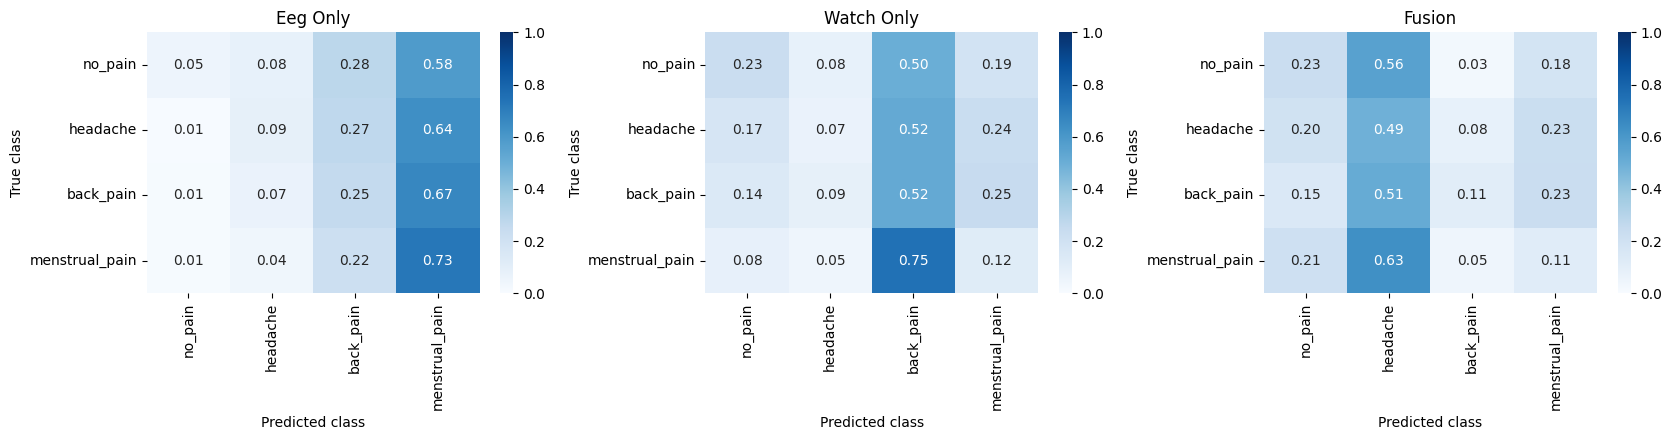

In [28]:
# Plot normalized confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, model_name in zip(
    axes,
    ["eeg_only", "watch_only", "fusion"]
):
    confusion_df = evaluate.confusion(
        y_int,
        all_predictions[model_name],
        normalize="true"
    )

    sns.heatmap(
        confusion_df,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=ax
    )

    ax.set_title(model_name.replace("_", " ").title())
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

plt.tight_layout()
plt.show()

In [29]:
# Show per-class F1
class_f1_columns = [
    f"f1_{class_name}"
    for class_name in config.PAIN_CLASSES
]

per_class_table = (
    results_df
    .groupby("model")[class_f1_columns]
    .mean()
    .round(3)
)

display(per_class_table)

,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain
model,,,,
eeg_only,0.068,0.128,0.267,0.248
fusion,0.195,0.383,0.133,0.097
watch_only,0.186,0.108,0.347,0.091


In [30]:
# Save results
output_dir = Path(
    "/content/gdrive/MyDrive/Colab Notebooks/"
    "AI570_Deep_Learning/TeamProject/fusion_results"
)

output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    output_dir / "fusion_fold_results.csv",
    index=False
)

report_table.to_csv(
    output_dir / "fusion_summary.csv",
    index=False
)

per_class_table.to_csv(
    output_dir / "fusion_per_class_f1.csv"
)

print("Results saved to:", output_dir)

Results saved to: /content/gdrive/MyDrive/Colab Notebooks/AI570_Deep_Learning/TeamProject/fusion_results


# Test 2: Best model comparison
## This test evaluate the branch only best models and the fusion model using the same 77 paired subjects

### Model used:
* EEG: TCN model (Best EEG model by macro-F1)
* Watch: LightGBM (Best available watch model)
* Dual-branch CNN: Multimodel fusion model

In [32]:
import gc
import time
from pathlib import Path

import keras
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from painnet import config, evaluate, models, windows

In [33]:
# Confirm that the earlier variables are available:
print("EEG:", X_eeg.shape)
print("Wristband:", X_watch.shape)
print("Subjects:", len(np.unique(groups)))
print("Folds:", len(cv_folds))

assert len(cv_folds) == 5
assert len(X_eeg) == len(X_watch) == len(y_int) == len(groups)

EEG: (5936, 60, 10)
Wristband: (5936, 240, 6)
Subjects: 77
Folds: 5


In [34]:
# ensures that no subject crosses training, validation, or testing.
for fold_number, (train_idx, val_idx, test_idx) in enumerate(
    cv_folds,
    start=1
):
    train_subjects = set(groups[train_idx])
    val_subjects = set(groups[val_idx])
    test_subjects = set(groups[test_idx])

    assert train_subjects.isdisjoint(val_subjects)
    assert train_subjects.isdisjoint(test_subjects)
    assert val_subjects.isdisjoint(test_subjects)

    print(
        f"Fold {fold_number}: "
        f"train={len(train_subjects)} subjects, "
        f"validation={len(val_subjects)} subjects, "
        f"test={len(test_subjects)} subjects"
    )

Fold 1: train=47 subjects, validation=15 subjects, test=15 subjects
Fold 2: train=46 subjects, validation=16 subjects, test=15 subjects
Fold 3: train=45 subjects, validation=16 subjects, test=16 subjects
Fold 4: train=47 subjects, validation=14 subjects, test=16 subjects
Fold 5: train=46 subjects, validation=16 subjects, test=15 subjects


In [35]:
# Prepare the wristband features for LightGBM
X_watch_tabular = windows.to_tabular(X_watch)

print("Raw wristband shape:", X_watch.shape)
print("LightGBM feature shape:", X_watch_tabular.shape)

Raw wristband shape: (5936, 240, 6)
LightGBM feature shape: (5936, 24)


In [37]:
# Define a common result-recording function
def make_result_row(
    model_name,
    fold_number,
    y_true,
    y_pred,
    train_idx,
    val_idx,
    test_idx,
    seconds,
    epochs_ran=None
):
    return {
        "model": model_name,
        "fold": fold_number,
        **evaluate.fold_metrics(y_true, y_pred),
        **evaluate.per_class_f1(y_true, y_pred),
        "epochs_ran": epochs_ran,
        "train_subjects": len(set(groups[train_idx])),
        "validation_subjects": len(set(groups[val_idx])),
        "test_subjects": len(set(groups[test_idx])),
        "seconds": seconds
    }

In [38]:
# Define the EEG TCN experiment: This uses the repository’s selected EEG architecture: models.build_tcn().
def run_eeg_tcn(
    folds,
    epochs=60,
    batch_size=64,
    verbose=2
):
    model_name = "eeg_tcn"
    fold_rows = []

    oof_predictions = np.full(len(y_int), -1, dtype=int)
    oof_probabilities = np.full(
        (len(y_int), len(config.PAIN_CLASSES)),
        np.nan,
        dtype=np.float32
    )

    histories = []

    for fold_number, (train_idx, val_idx, test_idx) in enumerate(
        folds,
        start=1
    ):
        print(f"\nEEG TCN — fold {fold_number}/{len(folds)}")
        start_time = time.time()

        keras.backend.clear_session()

        model = models.build_tcn(X_eeg.shape[1:])
        model = models.compile_model(model)

        history = model.fit(
            X_eeg[train_idx],
            y_int[train_idx],

            validation_data=(
                X_eeg[val_idx],
                y_int[val_idx]
            ),

            epochs=epochs,
            batch_size=batch_size,
            class_weight=windows.class_weights(y_int[train_idx]),
            callbacks=models.default_callbacks(patience=8),
            verbose=verbose
        )

        probabilities = model.predict(
            X_eeg[test_idx],
            batch_size=batch_size,
            verbose=0
        )

        predictions = probabilities.argmax(axis=1)

        oof_predictions[test_idx] = predictions
        oof_probabilities[test_idx] = probabilities

        row = make_result_row(
            model_name=model_name,
            fold_number=fold_number,
            y_true=y_int[test_idx],
            y_pred=predictions,
            train_idx=train_idx,
            val_idx=val_idx,
            test_idx=test_idx,
            seconds=time.time() - start_time,
            epochs_ran=len(history.history["loss"])
        )

        fold_rows.append(row)
        histories.append(history.history)

        print(
            f"Macro-F1={row['macro_f1']:.3f} | "
            f"Balanced accuracy={row['balanced_acc']:.3f} | "
            f"Accuracy={row['accuracy']:.3f} | "
            f"Epochs={row['epochs_ran']}"
        )

        del model
        keras.backend.clear_session()
        gc.collect()

    assert np.all(oof_predictions >= 0)

    return (
        pd.DataFrame(fold_rows),
        oof_predictions,
        oof_probabilities,
        histories
    )

In [39]:
# Define the wristband LightGBM experiment: This reproduces the selected wristband pipeline and hyperparameters.
def run_watch_lightgbm(folds):
    model_name = "watch_lightgbm"
    fold_rows = []

    oof_predictions = np.full(len(y_int), -1, dtype=int)
    oof_probabilities = np.full(
        (len(y_int), len(config.PAIN_CLASSES)),
        np.nan,
        dtype=np.float32
    )

    for fold_number, (train_idx, val_idx, test_idx) in enumerate(
        folds,
        start=1
    ):
        print(f"\nWristband LightGBM — fold {fold_number}/{len(folds)}")
        start_time = time.time()

        class_weight_dict = windows.class_weights(
            y_int[train_idx]
        )

        sample_weights = np.asarray([
            class_weight_dict[int(label)]
            for label in y_int[train_idx]
        ])

        model = lgb.LGBMClassifier(
            objective="multiclass",
            num_class=len(config.PAIN_CLASSES),
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=15,
            min_child_samples=40,
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            random_state=config.SEED,
            verbose=-1
        )

        model.fit(
            X_watch_tabular[train_idx],
            y_int[train_idx],
            sample_weight=sample_weights
        )

        predictions = model.predict(
            X_watch_tabular[test_idx]
        ).astype(int)

        probabilities = model.predict_proba(
            X_watch_tabular[test_idx]
        )

        oof_predictions[test_idx] = predictions
        oof_probabilities[test_idx] = probabilities

        row = make_result_row(
            model_name=model_name,
            fold_number=fold_number,
            y_true=y_int[test_idx],
            y_pred=predictions,
            train_idx=train_idx,
            val_idx=val_idx,
            test_idx=test_idx,
            seconds=time.time() - start_time
        )

        fold_rows.append(row)

        print(
            f"Macro-F1={row['macro_f1']:.3f} | "
            f"Balanced accuracy={row['balanced_acc']:.3f} | "
            f"Accuracy={row['accuracy']:.3f}"
        )

        del model
        gc.collect()

    assert np.all(oof_predictions >= 0)

    return (
        pd.DataFrame(fold_rows),
        oof_predictions,
        oof_probabilities
    )

In [40]:
# Define the dual-branch fusion CNN experiment
def run_fusion_cnn(
    folds,
    epochs=60,
    batch_size=64,
    verbose=2
):
    model_name = "fusion_cnn"
    fold_rows = []

    oof_predictions = np.full(len(y_int), -1, dtype=int)
    oof_probabilities = np.full(
        (len(y_int), len(config.PAIN_CLASSES)),
        np.nan,
        dtype=np.float32
    )

    histories = []

    for fold_number, (train_idx, val_idx, test_idx) in enumerate(
        folds,
        start=1
    ):
        print(f"\nFusion CNN — fold {fold_number}/{len(folds)}")
        start_time = time.time()

        keras.backend.clear_session()

        model = models.build_fusion(
            X_eeg.shape[1:],
            X_watch.shape[1:]
        )
        model = models.compile_model(model)

        history = model.fit(
            [
                X_eeg[train_idx],
                X_watch[train_idx]
            ],
            y_int[train_idx],

            validation_data=(
                [
                    X_eeg[val_idx],
                    X_watch[val_idx]
                ],
                y_int[val_idx]
            ),

            epochs=epochs,
            batch_size=batch_size,
            class_weight=windows.class_weights(y_int[train_idx]),
            callbacks=models.default_callbacks(patience=8),
            verbose=verbose
        )

        probabilities = model.predict(
            [
                X_eeg[test_idx],
                X_watch[test_idx]
            ],
            batch_size=batch_size,
            verbose=0
        )

        predictions = probabilities.argmax(axis=1)

        oof_predictions[test_idx] = predictions
        oof_probabilities[test_idx] = probabilities

        row = make_result_row(
            model_name=model_name,
            fold_number=fold_number,
            y_true=y_int[test_idx],
            y_pred=predictions,
            train_idx=train_idx,
            val_idx=val_idx,
            test_idx=test_idx,
            seconds=time.time() - start_time,
            epochs_ran=len(history.history["loss"])
        )

        fold_rows.append(row)
        histories.append(history.history)

        print(
            f"Macro-F1={row['macro_f1']:.3f} | "
            f"Balanced accuracy={row['balanced_acc']:.3f} | "
            f"Accuracy={row['accuracy']:.3f} | "
            f"Epochs={row['epochs_ran']}"
        )

        del model
        keras.backend.clear_session()
        gc.collect()

    assert np.all(oof_predictions >= 0)

    return (
        pd.DataFrame(fold_rows),
        oof_predictions,
        oof_probabilities,
        histories
    )

In [41]:
# Run the EEG TCN
tcn_results, tcn_predictions, tcn_probabilities, tcn_histories = (
    run_eeg_tcn(
        folds=cv_folds,
        epochs=60,
        batch_size=64,
        verbose=2
    )
)

display(tcn_results)


EEG TCN — fold 1/5
Epoch 1/60
57/57 - 21s - 366ms/step - accuracy: 0.3214 - loss: 1.2636 - val_accuracy: 0.1951 - val_loss: 1.4408 - learning_rate: 0.0010
Epoch 2/60
57/57 - 1s - 11ms/step - accuracy: 0.4120 - loss: 1.1489 - val_accuracy: 0.1315 - val_loss: 1.7817 - learning_rate: 0.0010
Epoch 3/60
57/57 - 1s - 9ms/step - accuracy: 0.4663 - loss: 1.0646 - val_accuracy: 0.2233 - val_loss: 1.6700 - learning_rate: 0.0010
Epoch 4/60
57/57 - 1s - 9ms/step - accuracy: 0.5260 - loss: 0.9797 - val_accuracy: 0.2674 - val_loss: 1.6340 - learning_rate: 0.0010
Epoch 5/60
57/57 - 1s - 10ms/step - accuracy: 0.5704 - loss: 0.9053 - val_accuracy: 0.2877 - val_loss: 1.5311 - learning_rate: 0.0010
Epoch 6/60
57/57 - 1s - 9ms/step - accuracy: 0.6268 - loss: 0.8049 - val_accuracy: 0.3151 - val_loss: 1.5129 - learning_rate: 5.0000e-04
Epoch 7/60
57/57 - 1s - 11ms/step - accuracy: 0.6599 - loss: 0.7561 - val_accuracy: 0.2780 - val_loss: 1.6760 - learning_rate: 5.0000e-04
Epoch 8/60
57/57 - 0s - 8ms/step - 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Macro-F1=0.141 | Balanced accuracy=0.141 | Accuracy=0.174 | Epochs=9

EEG TCN — fold 2/5
Epoch 1/60
56/56 - 18s - 330ms/step - accuracy: 0.3274 - loss: 1.1546 - val_accuracy: 0.1860 - val_loss: 1.3945 - learning_rate: 0.0010
Epoch 2/60
56/56 - 0s - 7ms/step - accuracy: 0.4110 - loss: 1.0066 - val_accuracy: 0.1780 - val_loss: 1.4438 - learning_rate: 0.0010
Epoch 3/60
56/56 - 0s - 7ms/step - accuracy: 0.4806 - loss: 0.8975 - val_accuracy: 0.1941 - val_loss: 1.5544 - learning_rate: 0.0010
Epoch 4/60
56/56 - 0s - 7ms/step - accuracy: 0.5411 - loss: 0.8132 - val_accuracy: 0.1989 - val_loss: 1.6217 - learning_rate: 0.0010
Epoch 5/60
56/56 - 0s - 7ms/step - accuracy: 0.5802 - loss: 0.7431 - val_accuracy: 0.2149 - val_loss: 1.7690 - learning_rate: 0.0010
Epoch 6/60
56/56 - 1s - 9ms/step - accuracy: 0.6461 - loss: 0.6489 - val_accuracy: 0.2334 - val_loss: 1.8034 - learning_rate: 5.0000e-04
Epoch 7/60
56/56 - 1s - 9ms/step - accuracy: 0.6720 - loss: 0.6007 - val_accuracy: 0.2398 - val_loss: 1.83

,model,fold,macro_f1,weighted_f1,balanced_acc,accuracy,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain,epochs_ran,train_subjects,validation_subjects,test_subjects,seconds
0,eeg_tcn,1,0.141222,0.252582,0.141380,0.174061,0.055944,0.225865,0.283077,0.000000,9,47,15,15,27.583616
1,eeg_tcn,2,0.192996,0.179706,0.261558,0.222515,0.096618,0.173913,0.187166,0.314286,9,46,16,15,25.192711
2,eeg_tcn,3,0.214954,0.257326,0.271417,0.274941,0.120401,0.335526,0.075472,0.328417,9,45,16,16,28.268587
3,eeg_tcn,4,0.149396,0.127109,0.246834,0.174334,0.273743,0.082262,0.029289,0.212291,9,47,14,16,28.351692
4,eeg_tcn,5,0.183746,0.179203,0.287955,0.216143,0.145215,0.190813,0.117647,0.281310,9,46,16,15,25.557368


In [42]:
# Run wristband LightGBM
lgbm_results, lgbm_predictions, lgbm_probabilities = (
    run_watch_lightgbm(cv_folds)
)

display(lgbm_results)


Wristband LightGBM — fold 1/5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Macro-F1=0.116 | Balanced accuracy=0.188 | Accuracy=0.153

Wristband LightGBM — fold 2/5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro-F1=0.186 | Balanced accuracy=0.228 | Accuracy=0.261

Wristband LightGBM — fold 3/5


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro-F1=0.241 | Balanced accuracy=0.269 | Accuracy=0.264

Wristband LightGBM — fold 5/5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro-F1=0.331 | Balanced accuracy=0.327 | Accuracy=0.352


,model,fold,macro_f1,weighted_f1,balanced_acc,accuracy,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain,epochs_ran,train_subjects,validation_subjects,test_subjects,seconds
0,watch_lightgbm,1,0.115810,0.179124,0.188311,0.152730,0.093264,0.184573,0.185404,0.000000,None,47,15,15,2.185531
1,watch_lightgbm,2,0.185588,0.199003,0.227958,0.261214,0.069930,0.389525,0.150820,0.132075,None,46,16,15,2.184129
2,watch_lightgbm,3,0.213611,0.235722,0.263488,0.238020,0.220779,0.290206,0.312891,0.030568,None,45,16,16,2.194163
3,watch_lightgbm,4,0.241258,0.245193,0.269310,0.263923,0.027778,0.291124,0.340120,0.306011,None,47,14,16,3.145574
4,watch_lightgbm,5,0.331291,0.362955,0.327184,0.352466,0.311628,0.468787,0.259036,0.285714,None,46,16,15,2.150888


In [44]:
# Run the dual-branch CNN
# If your earlier three-CNN comparison already produced the fusion results using these same cv_folds, you can reuse them. Otherwise, run:
fusion_results, fusion_predictions, fusion_probabilities, fusion_histories = (
    run_fusion_cnn(
        folds=cv_folds,
        epochs=60,
        batch_size=64,
        verbose=2
    )
)

display(fusion_results)


Fusion CNN — fold 1/5
Epoch 1/60
57/57 - 11s - 188ms/step - accuracy: 0.3258 - loss: 1.2261 - val_accuracy: 0.3822 - val_loss: 1.3728 - learning_rate: 0.0010
Epoch 2/60
57/57 - 0s - 7ms/step - accuracy: 0.4225 - loss: 1.1145 - val_accuracy: 0.2445 - val_loss: 1.3918 - learning_rate: 0.0010
Epoch 3/60
57/57 - 0s - 7ms/step - accuracy: 0.5059 - loss: 1.0207 - val_accuracy: 0.2348 - val_loss: 1.4218 - learning_rate: 0.0010
Epoch 4/60
57/57 - 0s - 7ms/step - accuracy: 0.5720 - loss: 0.9210 - val_accuracy: 0.2251 - val_loss: 1.5570 - learning_rate: 0.0010
Epoch 5/60
57/57 - 0s - 7ms/step - accuracy: 0.6205 - loss: 0.8385 - val_accuracy: 0.2321 - val_loss: 1.6246 - learning_rate: 0.0010
Epoch 6/60
57/57 - 0s - 7ms/step - accuracy: 0.6797 - loss: 0.7288 - val_accuracy: 0.2445 - val_loss: 1.7006 - learning_rate: 5.0000e-04
Epoch 7/60
57/57 - 1s - 9ms/step - accuracy: 0.7056 - loss: 0.6863 - val_accuracy: 0.2489 - val_loss: 1.7387 - learning_rate: 5.0000e-04
Epoch 8/60
57/57 - 1s - 9ms/step - 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Macro-F1=0.146 | Balanced accuracy=0.207 | Accuracy=0.237 | Epochs=9

Fusion CNN — fold 2/5
Epoch 1/60
56/56 - 11s - 197ms/step - accuracy: 0.3559 - loss: 1.1209 - val_accuracy: 0.1484 - val_loss: 1.4401 - learning_rate: 0.0010
Epoch 2/60
56/56 - 0s - 9ms/step - accuracy: 0.4690 - loss: 0.9790 - val_accuracy: 0.1524 - val_loss: 1.4872 - learning_rate: 0.0010
Epoch 3/60
56/56 - 0s - 7ms/step - accuracy: 0.5267 - loss: 0.8687 - val_accuracy: 0.1764 - val_loss: 1.5666 - learning_rate: 0.0010
Epoch 4/60
56/56 - 0s - 7ms/step - accuracy: 0.6047 - loss: 0.7544 - val_accuracy: 0.2037 - val_loss: 1.6782 - learning_rate: 0.0010
Epoch 5/60
56/56 - 0s - 7ms/step - accuracy: 0.6422 - loss: 0.6586 - val_accuracy: 0.2269 - val_loss: 1.8518 - learning_rate: 0.0010
Epoch 6/60
56/56 - 0s - 7ms/step - accuracy: 0.6954 - loss: 0.5758 - val_accuracy: 0.2269 - val_loss: 1.9038 - learning_rate: 5.0000e-04
Epoch 7/60
56/56 - 0s - 7ms/step - accuracy: 0.7123 - loss: 0.5283 - val_accuracy: 0.2358 - val_loss: 1

,model,fold,macro_f1,weighted_f1,balanced_acc,accuracy,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain,epochs_ran,train_subjects,validation_subjects,test_subjects,seconds
0,fusion_cnn,1,0.145687,0.262800,0.206800,0.237201,0.000000,0.315556,0.267191,0.000000,9,47,15,15,17.889549
1,fusion_cnn,2,0.172334,0.206471,0.215427,0.267370,0.140659,0.413333,0.041667,0.093677,9,46,16,15,16.320253
2,fusion_cnn,3,0.170423,0.238905,0.185735,0.252946,0.222785,0.414950,0.043956,0.000000,10,45,16,16,21.111941
3,fusion_cnn,4,0.219018,0.214115,0.250780,0.228410,0.267806,0.291498,0.135714,0.181053,9,47,14,16,17.053779
4,fusion_cnn,5,0.301457,0.340560,0.313944,0.367713,0.348754,0.468864,0.161404,0.226804,10,46,16,15,16.959891


In [45]:
# Combine the fold-level results
results_df = pd.concat(
    [
        tcn_results,
        lgbm_results,
        fusion_results
    ],
    ignore_index=True
)

display(results_df)

,model,fold,macro_f1,weighted_f1,balanced_acc,accuracy,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain,epochs_ran,train_subjects,validation_subjects,test_subjects,seconds
0,eeg_tcn,1,0.141222,0.252582,0.141380,0.174061,0.055944,0.225865,0.283077,0.000000,9,47,15,15,27.583616
1,eeg_tcn,2,0.192996,0.179706,0.261558,0.222515,0.096618,0.173913,0.187166,0.314286,9,46,16,15,25.192711
2,eeg_tcn,3,0.214954,0.257326,0.271417,0.274941,0.120401,0.335526,0.075472,0.328417,9,45,16,16,28.268587
3,eeg_tcn,4,0.149396,0.127109,0.246834,0.174334,0.273743,0.082262,0.029289,0.212291,9,47,14,16,28.351692
4,eeg_tcn,5,0.183746,0.179203,0.287955,0.216143,0.145215,0.190813,0.117647,0.281310,9,46,16,15,25.557368
5,watch_lightgbm,1,0.115810,0.179124,0.188311,0.152730,0.093264,0.184573,0.185404,0.000000,None,47,15,15,2.185531
6,watch_lightgbm,2,0.185588,0.199003,0.227958,0.261214,0.069930,0.389525,0.150820,0.132075,None,46,16,15,2.184129
7,watch_lightgbm,3,0.213611,0.235722,0.263488,0.238020,0.220779,0.290206,0.312891,0.030568,None,45,16,16,2.194163
8,watch_lightgbm,4,0.241258,0.245193,0.269310,0.263923,0.027778,0.291124,0.340120,0.306011,None,47,14,16,3.145574
9,watch_lightgbm,5,0.331291,0.362955,0.327184,0.352466,0.311628,0.468787,0.259036,0.285714,None,46,16,15,2.150888


In [46]:
# Create the primary comparison table
metric_columns = [
    "macro_f1",
    "balanced_acc",
    "weighted_f1",
    "accuracy"
]

model_order = [
    "eeg_tcn",
    "watch_lightgbm",
    "fusion_cnn"
]

report_rows = []

for model_name in model_order:
    model_results = results_df[
        results_df["model"] == model_name
    ]

    row = {"model": model_name}

    for metric in metric_columns:
        mean_value = model_results[metric].mean()
        std_value = model_results[metric].std()

        row[metric] = (
            f"{mean_value:.3f} ± {std_value:.3f}"
        )

    report_rows.append(row)

comparison_table = pd.DataFrame(report_rows)

comparison_table["model"] = comparison_table["model"].replace({
    "eeg_tcn": "EEG TCN",
    "watch_lightgbm": "Wristband LightGBM",
    "fusion_cnn": "Dual-branch CNN"
})

display(comparison_table)

,model,macro_f1,balanced_acc,weighted_f1,accuracy
0,EEG TCN,0.176 ± 0.031,0.242 ± 0.058,0.199 ± 0.055,0.212 ± 0.042
1,Wristband LightGBM,0.218 ± 0.079,0.255 ± 0.052,0.244 ± 0.072,0.254 ± 0.071
2,Dual-branch CNN,0.202 ± 0.062,0.235 ± 0.050,0.253 ± 0.054,0.271 ± 0.056


In [47]:
# Compare fusion within each fold
fold_comparison = results_df.pivot(
    index="fold",
    columns="model",
    values="macro_f1"
).reset_index()

fold_comparison["fusion_minus_tcn"] = (
    fold_comparison["fusion_cnn"]
    - fold_comparison["eeg_tcn"]
)

fold_comparison["fusion_minus_lightgbm"] = (
    fold_comparison["fusion_cnn"]
    - fold_comparison["watch_lightgbm"]
)

display(fold_comparison.round(3))

model,fold,eeg_tcn,fusion_cnn,watch_lightgbm,fusion_minus_tcn,fusion_minus_lightgbm
0,1,0.141,0.146,0.116,0.004,0.030
1,2,0.193,0.172,0.186,-0.021,-0.013
2,3,0.215,0.170,0.214,-0.045,-0.043
3,4,0.149,0.219,0.241,0.070,-0.022
4,5,0.184,0.301,0.331,0.118,-0.030


In [48]:
# Summarize the differences:
fusion_tcn_mean_difference = (
    fold_comparison["fusion_minus_tcn"].mean()
)

fusion_lgbm_mean_difference = (
    fold_comparison["fusion_minus_lightgbm"].mean()
)

fusion_beats_tcn = (
    fold_comparison["fusion_minus_tcn"] > 0
).sum()

fusion_beats_lgbm = (
    fold_comparison["fusion_minus_lightgbm"] > 0
).sum()

print(
    "Fusion minus EEG TCN:",
    f"{fusion_tcn_mean_difference:.3f}"
)

print(
    "Fusion minus wristband LightGBM:",
    f"{fusion_lgbm_mean_difference:.3f}"
)

print(
    f"Fusion beat EEG TCN in "
    f"{fusion_beats_tcn}/5 folds"
)

print(
    f"Fusion beat wristband LightGBM in "
    f"{fusion_beats_lgbm}/5 folds"
)

Fusion minus EEG TCN: 0.025
Fusion minus wristband LightGBM: -0.016
Fusion beat EEG TCN in 3/5 folds
Fusion beat wristband LightGBM in 1/5 folds


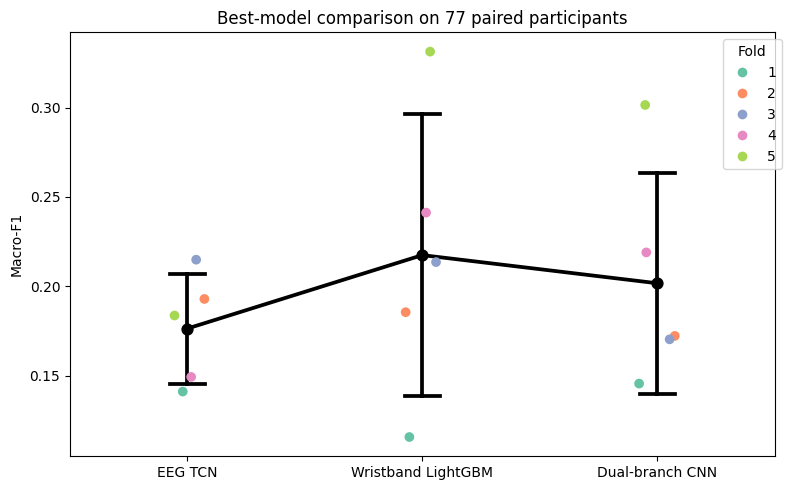

In [49]:
# Plot fold-level macro-F1
plot_df = results_df.copy()

plot_df["Model"] = plot_df["model"].replace({
    "eeg_tcn": "EEG TCN",
    "watch_lightgbm": "Wristband LightGBM",
    "fusion_cnn": "Dual-branch CNN"
})

plt.figure(figsize=(8, 5))

sns.pointplot(
    data=plot_df,
    x="Model",
    y="macro_f1",
    errorbar="sd",
    capsize=0.15,
    color="black"
)

sns.stripplot(
    data=plot_df,
    x="Model",
    y="macro_f1",
    hue="fold",
    palette="Set2",
    size=7,
    jitter=0.08
)

plt.ylabel("Macro-F1")
plt.xlabel("")
plt.title("Best-model comparison on 77 paired participants")
plt.legend(title="Fold", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

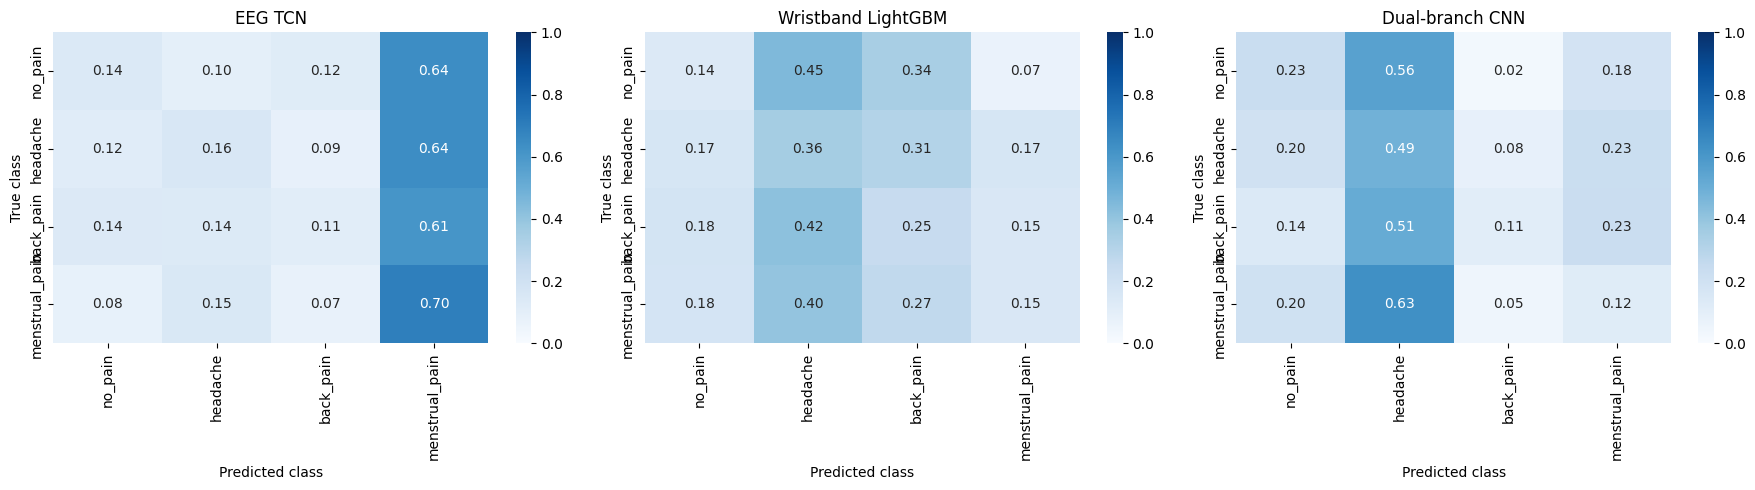

In [50]:
# Plot normalized confusion matrices
all_predictions = {
    "EEG TCN": tcn_predictions,
    "Wristband LightGBM": lgbm_predictions,
    "Dual-branch CNN": fusion_predictions
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_label, predictions) in zip(
    axes,
    all_predictions.items()
):
    confusion_df = evaluate.confusion(
        y_int,
        predictions,
        normalize="true"
    )

    sns.heatmap(
        confusion_df,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=ax
    )

    ax.set_title(model_label)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

plt.tight_layout()
plt.show()

In [51]:
# Compare per-class F1
class_f1_columns = [
    f"f1_{class_name}"
    for class_name in config.PAIN_CLASSES
]

per_class_summary = (
    results_df
    .groupby("model")[class_f1_columns]
    .mean()
    .reindex(model_order)
    .round(3)
)

per_class_summary.index = [
    "EEG TCN",
    "Wristband LightGBM",
    "Dual-branch CNN"
]

display(per_class_summary)

,f1_no_pain,f1_headache,f1_back_pain,f1_menstrual_pain
EEG TCN,0.138,0.202,0.139,0.227
Wristband LightGBM,0.145,0.325,0.250,0.151
Dual-branch CNN,0.196,0.381,0.130,0.100


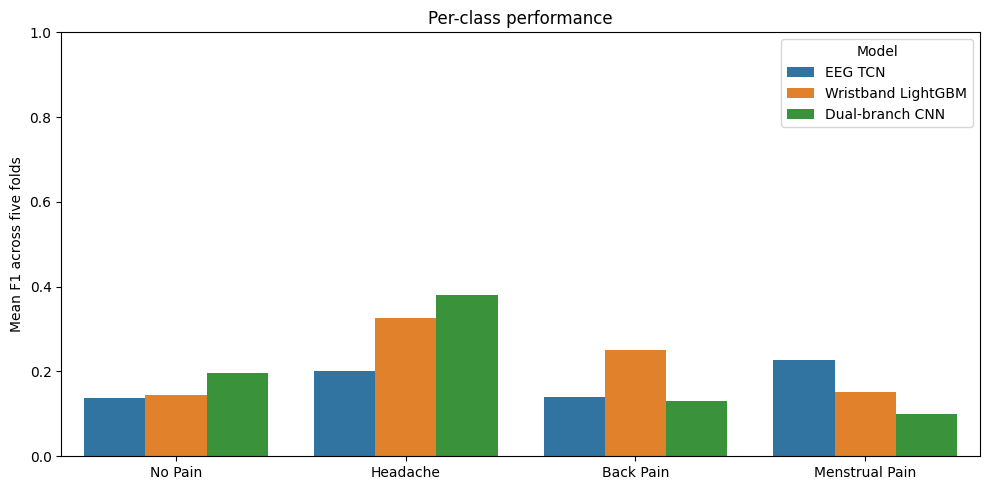

In [52]:
# Create a figure:
per_class_plot = (
    per_class_summary
    .reset_index(names="Model")
    .melt(
        id_vars="Model",
        var_name="Pain class",
        value_name="Mean F1"
    )
)

per_class_plot["Pain class"] = (
    per_class_plot["Pain class"]
    .str.replace("f1_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=per_class_plot,
    x="Pain class",
    y="Mean F1",
    hue="Model"
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Mean F1 across five folds")
plt.title("Per-class performance")
plt.tight_layout()
plt.show()

In [53]:
# save results
output_dir = Path(
    "/content/gdrive/MyDrive/Colab Notebooks/"
    "AI570_Deep_Learning/TeamProject/best_model_results"
)

output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    output_dir / "best_model_fold_results.csv",
    index=False
)

comparison_table.to_csv(
    output_dir / "best_model_summary.csv",
    index=False
)

fold_comparison.to_csv(
    output_dir / "best_model_fold_comparison.csv",
    index=False
)

per_class_summary.to_csv(
    output_dir / "best_model_per_class_f1.csv"
)

np.save(
    output_dir / "tcn_oof_predictions.npy",
    tcn_predictions
)

np.save(
    output_dir / "lightgbm_oof_predictions.npy",
    lgbm_predictions
)

np.save(
    output_dir / "fusion_oof_predictions.npy",
    fusion_predictions
)

print("Results saved to:", output_dir)

Results saved to: /content/gdrive/MyDrive/Colab Notebooks/AI570_Deep_Learning/TeamProject/best_model_results


Discussion: From these metrics, the Wristband LightGBM generally performs better in terms of macro-F1 and balanced accuracy compared to the EEG TCN. The Dual-branch CNN shows the highest overall accuracy and weighted F1, suggesting it performs well across classes, but its macro-F1 is slightly lower than the Wristband LightGBM. The variability (standard deviation) is also an important factor, with the Wristband LightGBM having a higher standard deviation for macro-F1, indicating more variance across folds.

Regarding the per-class F1 scores:

* For 'No Pain', the Dual-branch CNN performs best (0.196), followed by Wristband LightGBM (0.145) and EEG TCN (0.138).
* For 'Headache', the Dual-branch CNN leads significantly (0.381), with Wristband LightGBM (0.325) and EEG TCN (0.202) following.
* For 'Back Pain', Wristband LightGBM has the highest F1 (0.250), followed by EEG TCN (0.139) and Dual-branch CNN (0.130).
* For 'Menstrual Pain', EEG TCN performs best (0.227), followed by Wristband LightGBM (0.151) and Dual-branch CNN (0.100).

In summary, the performance varies by class and metric. The Dual-branch CNN seems strong for 'No Pain' and 'Headache', while the Wristband LightGBM excels at 'Back Pain', and EEG TCN for 'Menstrual Pain'. This suggests that different modalities and models have varying strengths across pain types.